In [22]:
!pip install mne -q
!pip install "decorator>=5.1" -q

In [23]:
import mne

# Verifica a versão instalada
print(f"Versão do MNE: {mne.__version__}")

print("Sucesso! O MNE está pronto para uso.")

Versão do MNE: 1.13.2
Dados de exemplo do MNE configurados na pasta: /root/mne_data/MNE-sample-data
Sucesso! O MNE está pronto para uso.


In [24]:
import mne

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
from pathlib import Path

caminhos_edf = (Path.cwd() / "chb24_01.edf", Path.cwd().parent / "chb24_01.edf")
arquivo_edf = next((caminho for caminho in caminhos_edf if caminho.is_file()), None)
if arquivo_edf is None:
    raise FileNotFoundError("Não foi possível localizar chb24_01.edf na pasta do notebook ou na raiz do projeto.")

raw = mne.io.read_raw_edf(arquivo_edf, preload=True)
raw

Extracting EDF parameters from chb24_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_5521/2877399466.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(arquivo_edf, preload=True)


<RawEDF | chb24_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [27]:
print(raw.info)
print(raw.ch_names)
print(f"Taxa de amostragem: {raw.info['sfreq']} Hz")

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-01-25 16:26:28 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Taxa de amostragem: 256.0 Hz


os códigos FP, F, P, T, C são códigos neuro encefalograma que significam:
F = Frontal
FP = frontal polar
P = parietal
T = temporal
C = hospital

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


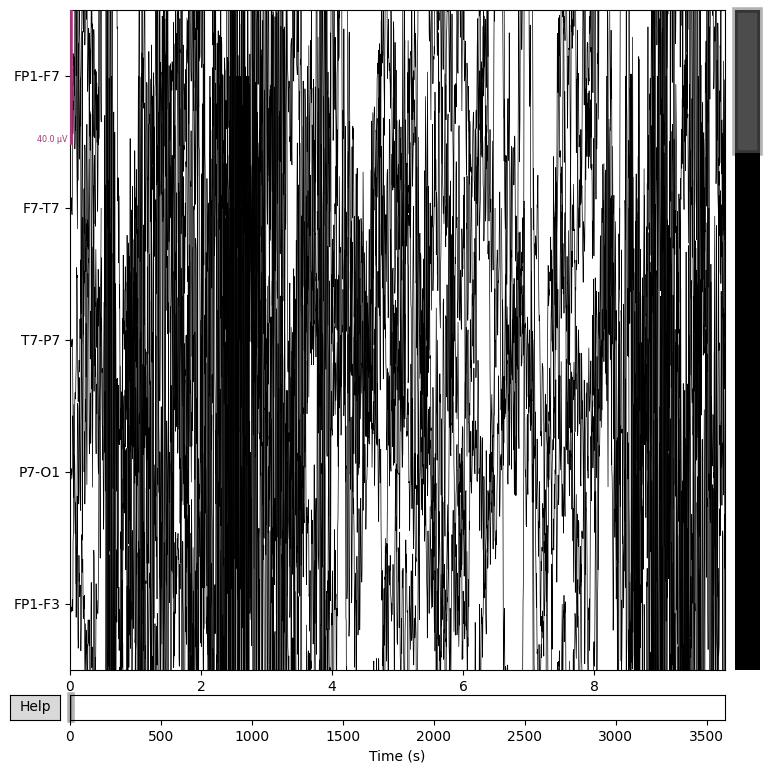

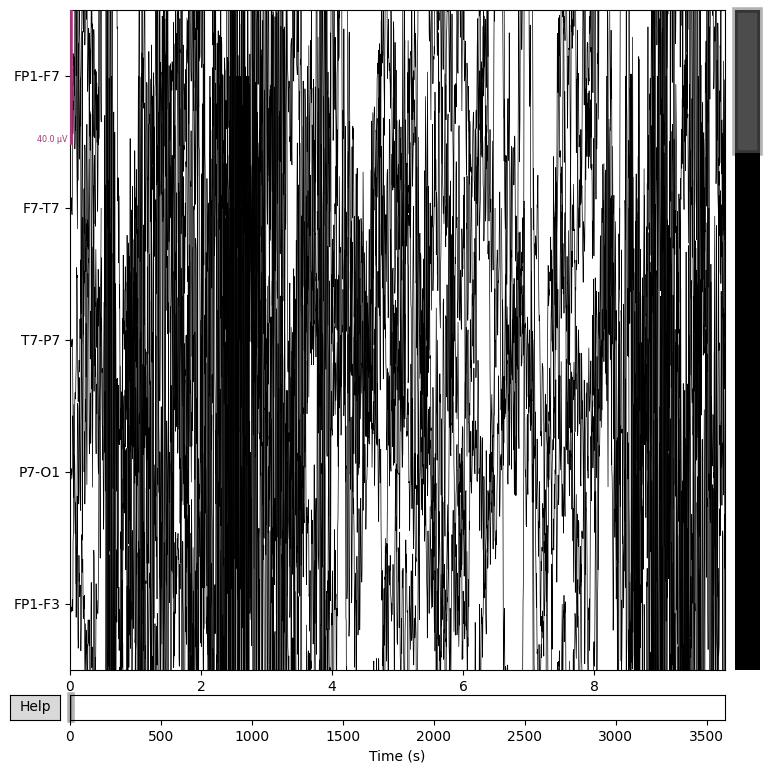

In [28]:
raw.plot(duration=10, n_channels=5)

In [38]:
data_filtrado = raw.get_data()
data_filtrado.shape

(23, 921600)

In [30]:
print("Número de canais:", data_filtrado.shape[0])
print("Número de amostras:", data_filtrado.shape[1])

Número de canais: 23
Número de amostras: 921600


In [32]:
caminhos_resumo = (Path.cwd() / "chb24-summary.txt", Path.cwd().parent / "chb24-summary.txt")
arquivo_resumo = next((caminho for caminho in caminhos_resumo if caminho.is_file()), None)
if arquivo_resumo is None:
    raise FileNotFoundError("Não foi possível localizar chb24-summary.txt na pasta do notebook ou na raiz do projeto.")

with arquivo_resumo.open("r") as f:
  conteudo = f.readlines()

for linha in conteudo[:40]:
  print(linha.strip())

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb24_01.edf
Number of Seizures in File: 2
Seizure Start Time: 480 seconds
Seizure End Time: 505 seconds
Seizure Start Time: 2451 seconds
Seizure End Time: 2476 seconds

File Name: chb24_03.edf
Number of Seizures in File: 2
Seizure Start Time: 231 seconds
Seizure End Time: 260 seconds


In [33]:
seizure_intervals_sec = [
    (480, 505),
    (2451, 2476)
]

sfreq = raw.info["sfreq"]

Intervalos pra saber quando a crise acontece e o sfreq usado pra transformar o tempo em indice

In [39]:
canal_idx = 0
signal = data_filtrado[canal_idx]

In [40]:
time = np.arange(len(signal)) / sfreq

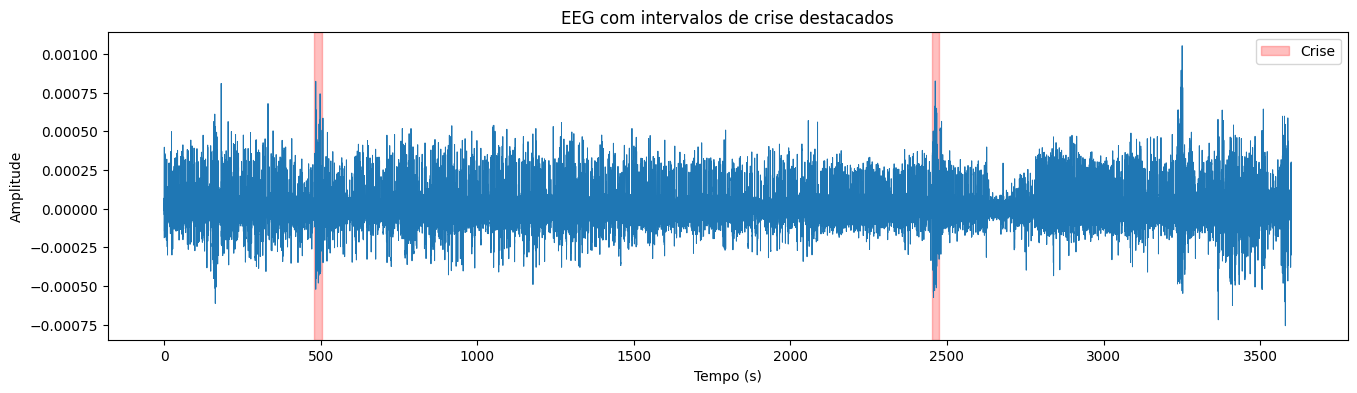

In [44]:
plt.figure(figsize=(16,4))
plt.plot(time, signal, linewidth=0.7)

for i, (start, end) in enumerate(seizure_intervals_sec):
  plt.axvspan(start, end, color="red", alpha=0.25,
              label="Crise" if i==0 else None)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG com intervalos de crise destacados")
plt.legend()
plt.show()

In [43]:
window_size = 256
step = 128

windows = []

for start in range(0, data_filtrado.shape[1] - window_size, step):
  segment = data_filtrado[:, start:start + window_size]
  windows.append(segment)

windows = np.array(windows)
windows.shape

(7198, 23, 256)

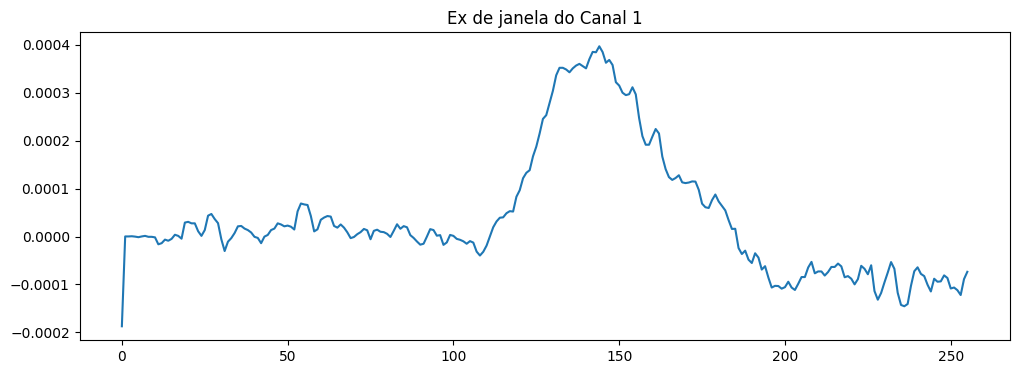

In [46]:
plt.figure(figsize=(12,4))
plt.plot(windows[0][0])
plt.title("Ex de janela do Canal 1")
plt.show()

In [47]:
print("Quantidade de janelas:", windows.shape[0])
print("Canais por janela:", windows.shape[1])
print("Pontos por janela:", windows.shape[2])

Quantidade de janelas: 7198
Canais por janela: 23
Pontos por janela: 256
